In [1]:
from scr.qsvdd_core.circuits import QSVDDCircuit
import numpy as np
from qiskit import transpile, QuantumCircuit
from qclib.util import get_cnot_count

In [2]:
n_qubits = 5
amplitudes = np.random.rand(32)
amplitudes /= np.linalg.norm(amplitudes)
# amplitudes = np.pad(amplitudes, (0, 32 - len(amplitudes)), mode='constant')
params = np.random.rand(9*n_qubits)
print(amplitudes)

[0.13058632 0.15910517 0.26490398 0.05366527 0.11482435 0.26029465
 0.22711104 0.0038237  0.15863578 0.30019346 0.23489559 0.14479396
 0.2785139  0.28524523 0.0316695  0.10173093 0.00437211 0.11556273
 0.18401444 0.221278   0.25929964 0.19969172 0.17436315 0.13816455
 0.25158799 0.11825639 0.15988499 0.04320124 0.04726295 0.00982334
 0.17268401 0.02592696]


In [3]:
q_circuit = QSVDDCircuit(n_qubits)

methods_map = {
    "BAA LowRank":          "baa_lowrank",
    "Bidirectional":        "bdsp",
    "Divide and Conquer":   "dcsp",
    "Isometry":             "isometry",
    "Qiskit Native":        "qiskit",
    "UCGE":                 "ucge"
}

original_circuits = {
    name: q_circuit.feature_mapping(amplitudes, method=method)
    for name, method in methods_map.items()
}

basis_gates = ['u', 'cx']
transpiled_circuits = {
    name: transpile(qc, basis_gates=basis_gates)
    for name, qc in original_circuits.items()
}

header = f"{' Quantum Feature Mapping Benchmarks ':=^60}"
print(f"\n{header}")
print(f"{'Method Strategy':<25} | {'CNOT Count':>12} | {'Circuit Depth':>14}")
print("-" * 60)

for name, qc in transpiled_circuits.items():
    cnot_count = qc.count_ops().get('cx', 0)
    depth = qc.depth()

    print(f"{name:<25} | {cnot_count:>12} | {depth:>12}")

print("=" * 60)


============ Quantum Feature Mapping Benchmarks ============
Method Strategy           |   CNOT Count |  Circuit Depth
------------------------------------------------------------
BAA LowRank               |           20 |           32
Bidirectional             |           94 |           74
Divide and Conquer        |          182 |           93
Isometry                  |           26 |           53
Qiskit Native             |           26 |           53
UCGE                      |           26 |           53


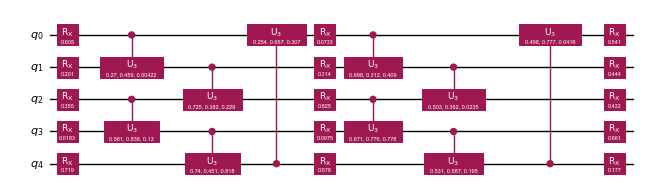

In [4]:
qc_ansatz = q_circuit.ansatz(params)
qc_ansatz.draw('mpl', scale=.5, fold=-1)

the ansatz_circuit has 20 CNOTs and depth of 21


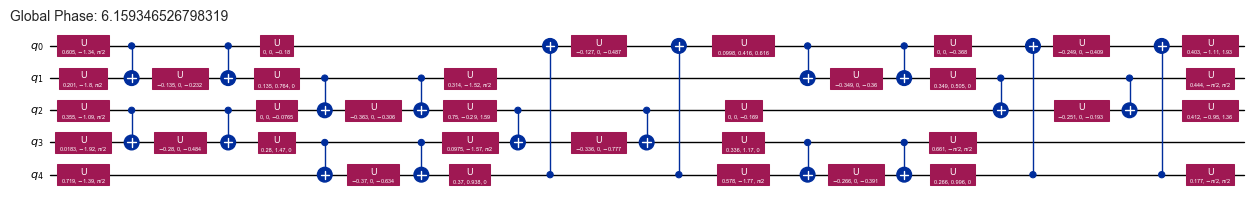

In [5]:
qc_ansatz_transpiled= transpile(qc_ansatz, basis_gates=['u', 'cx'])

print(
    'the ansatz_circuit has %d CNOTs and depth of %d'
    %(get_cnot_count(qc_ansatz_transpiled), qc_ansatz_transpiled.depth())
)

qc_ansatz_transpiled.draw('mpl', scale=.5, fold=-1)

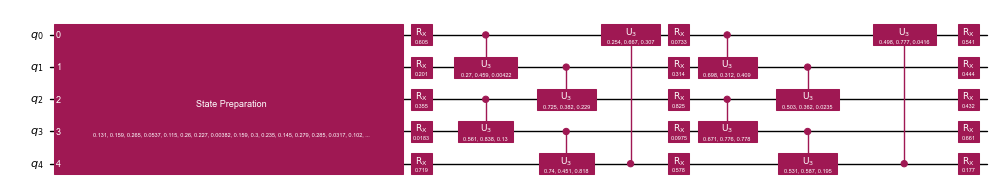

In [6]:
qnn = q_circuit.qc_complete_design(amplitudes, params)
qnn.draw('mpl', scale=.5, fold=-1)